In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from ttcrpy.rgrid import Grid3d

# Example 1 – Grid3d with float32 precision

Same 3-D layered model as Example 1 (40×40×40 voxels, linear vertical velocity gradient),
computed with both the default `float64` precision and the `float32` option.
Single precision roughly halves the memory footprint of the slowness field and
the output traveltime arrays; the accuracy loss is typically well below 0.1 % for
the traveltimes.

Raypaths and VTK export are omitted to keep the focus on the precision comparison.

In [2]:
N = 40       # number of voxels in each direction
dx = 0.5     # cell size

xn = np.arange(0, (N+1)*dx, dx)
yn = np.arange(0, (N+1)*dx, dx)
zn = np.arange(0, (N+1)*dx, dx)

# Vertical velocity gradient (same model as Example 1)
a = 1.0
V20 = 3.0
b = (V20 - a) / 20.0

slowness = np.empty((N,))
for n in range(N):
    z = 2*int(zn[n]/2) + 1
    slowness[n] = 1.0 / (a + b*z)
slowness = np.tile(slowness, N*N)          # float64
slowness_f = slowness.astype(np.float32)   # float32 copy

## Create grids

`Grid3d` is a factory: pass `dtype=np.float32` to get a `Grid3d_f` instance
that keeps all internal data in single precision.

In [3]:
# Double-precision grid (default)
grid_d = Grid3d(xn, yn, zn)
grid_d.set_slowness(slowness)

# Single-precision grid
grid_f = Grid3d(xn, yn, zn, dtype=np.float32)
grid_f.set_slowness(slowness_f)

print(f'grid_d type: {type(grid_d).__name__}')
print(f'grid_f type: {type(grid_f).__name__}')

grid_d type: Grid3d_d
grid_f type: Grid3d_f


## Define source and receivers

In [4]:
# One source
src = np.array([[0.5, 0.5, 0.5]])

# Surface spread + borehole receivers (same layout as Example 1)
rcv = np.c_[np.arange(1.5, 20.0),
            np.arange(1.5, 20.0),
            0.5 + np.zeros((19,))]
rcv = np.r_[rcv, np.c_[19.5 + np.zeros((19,)),
                        19.5 + np.zeros((19,)),
                        np.arange(1.5, 20.0)]]

# float32 copies for the single-precision grid
src_f = src.astype(np.float32)
rcv_f = rcv.astype(np.float32)

## Fast-Sweeping Method (FSM)

In [5]:
t0 = time.time()
tt_d = grid_d.raytrace(src, rcv)
time_d_fsm = time.time() - t0

t0 = time.time()
tt_f = grid_f.raytrace(src_f, rcv_f)
time_f_fsm = time.time() - t0

print(f'FSM float64: {time_d_fsm:.3f} s   output dtype: {tt_d.dtype}')
print(f'FSM float32: {time_f_fsm:.3f} s   output dtype: {tt_f.dtype}')

FSM float64: 0.764 s   output dtype: float64
FSM float32: 0.799 s   output dtype: float32


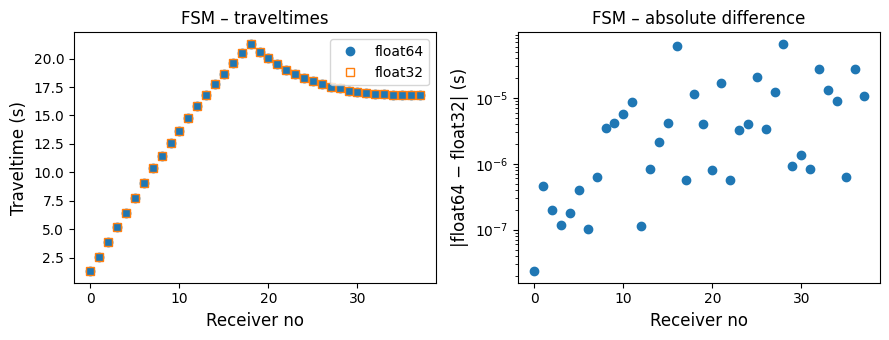

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

axes[0].plot(tt_d, 'o', label='float64')
axes[0].plot(tt_f, 's', label='float32', mfc='none')
axes[0].set_xlabel('Receiver no', fontsize=12)
axes[0].set_ylabel('Traveltime (s)', fontsize=12)
axes[0].legend()
axes[0].set_title('FSM – traveltimes')

axes[1].semilogy(np.abs(tt_d - tt_f.astype(np.float64)), 'o')
axes[1].set_xlabel('Receiver no', fontsize=12)
axes[1].set_ylabel('|float64 − float32| (s)', fontsize=12)
axes[1].set_title('FSM – absolute difference')

plt.tight_layout()
plt.show()

## Shortest-Path Method (SPM)

In [7]:
grid_d_spm = Grid3d(xn, yn, zn, method='SPM')
grid_f_spm = Grid3d(xn, yn, zn, method='SPM', dtype=np.float32)

t0 = time.time()
tt_d_spm = grid_d_spm.raytrace(src, rcv, slowness=slowness)
time_d_spm = time.time() - t0

t0 = time.time()
tt_f_spm = grid_f_spm.raytrace(src_f, rcv_f, slowness=slowness_f)
time_f_spm = time.time() - t0

print(f'SPM float64: {time_d_spm:.3f} s   output dtype: {tt_d_spm.dtype}')
print(f'SPM float32: {time_f_spm:.3f} s   output dtype: {tt_f_spm.dtype}')

SPM float64: 19.207 s   output dtype: float64
SPM float32: 17.062 s   output dtype: float32


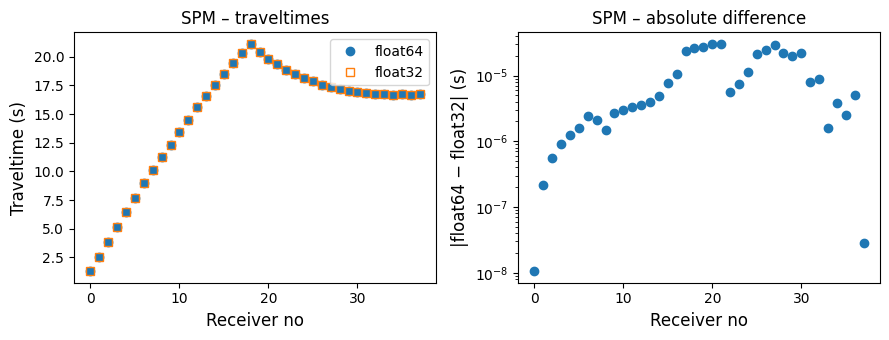

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

axes[0].plot(tt_d_spm, 'o', label='float64')
axes[0].plot(tt_f_spm, 's', label='float32', mfc='none')
axes[0].set_xlabel('Receiver no', fontsize=12)
axes[0].set_ylabel('Traveltime (s)', fontsize=12)
axes[0].legend()
axes[0].set_title('SPM – traveltimes')

axes[1].semilogy(np.abs(tt_d_spm - tt_f_spm.astype(np.float64)), 'o')
axes[1].set_xlabel('Receiver no', fontsize=12)
axes[1].set_ylabel('|float64 − float32| (s)', fontsize=12)
axes[1].set_title('SPM – absolute difference')

plt.tight_layout()
plt.show()

## Memory and dtype summary

In [9]:
print('Slowness array')
print(f'  float64: {slowness.nbytes / 1024:6.1f} kB')
print(f'  float32: {slowness_f.nbytes / 1024:6.1f} kB')
print()
print('Traveltime array (FSM)')
print(f'  float64: {tt_d.nbytes} bytes   dtype: {tt_d.dtype}')
print(f'  float32: {tt_f.nbytes} bytes   dtype: {tt_f.dtype}')
print()
print('Max absolute traveltime error')
print(f'  FSM: {np.max(np.abs(tt_d - tt_f.astype(np.float64))):.3e} s')
print(f'  SPM: {np.max(np.abs(tt_d_spm - tt_f_spm.astype(np.float64))):.3e} s')

Slowness array
  float64:  500.0 kB
  float32:  250.0 kB

Traveltime array (FSM)
  float64: 304 bytes   dtype: float64
  float32: 152 bytes   dtype: float32

Max absolute traveltime error
  FSM: 6.643e-05 s
  SPM: 3.045e-05 s
